In [1]:
import os
print(os.getcwd())


C:\Users\dell\OneDrive\Desktop\ML_PROJECTS


In [2]:
import pandas as pd
train_df = pd.read_csv("train.csv")
test_df = pd.read_csv("test.csv")
print(train_df.head())
print(test_df.head())



         date        high         low  momentum_index  beta_indicator  \
0  2012-06-22   24.797176  162.793195      153.349972       90.290064   
1  2013-02-27   84.148858   62.911473      123.066280       99.689780   
2  2010-07-19  162.714072    7.813419       50.140068      -30.373609   
3  2015-12-31 -128.017977  -38.679447      -21.881272     -173.386894   
4  2012-11-12  204.768157   -6.981525      -38.978256       64.867265   

   risk_premium     index  volatility_factor  technical_score  \
0    277.383362   62235.0         105.868473       128.280484   
1    116.635811   48784.0         116.700703         8.730951   
2    145.254746  233118.0         302.752221       -40.118103   
3   -123.314003   28867.0          -3.662459        81.801806   
4    -90.095079  182732.0        -157.223822       -76.111066   

   oscillator_value  liquidity_ratio        open  quant_index  trend_strength  \
0         38.359969       154.844720  122.656593  3817.034814      -48.017571   
1       

Train shape: (283085, 19)

Train info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 283085 entries, 0 to 283084
Data columns (total 19 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   date               281527 non-null  object 
 1   high               281545 non-null  float64
 2   low                281619 non-null  float64
 3   momentum_index     281630 non-null  float64
 4   beta_indicator     281646 non-null  float64
 5   risk_premium       281524 non-null  float64
 6   index              281564 non-null  float64
 7   volatility_factor  281566 non-null  float64
 8   technical_score    281571 non-null  float64
 9   oscillator_value   281620 non-null  float64
 10  liquidity_ratio    281572 non-null  float64
 11  open               281645 non-null  float64
 12  quant_index        281513 non-null  float64
 13  trend_strength     281592 non-null  float64
 14  market_sentiment   281615 non-null  float64
 15  close       

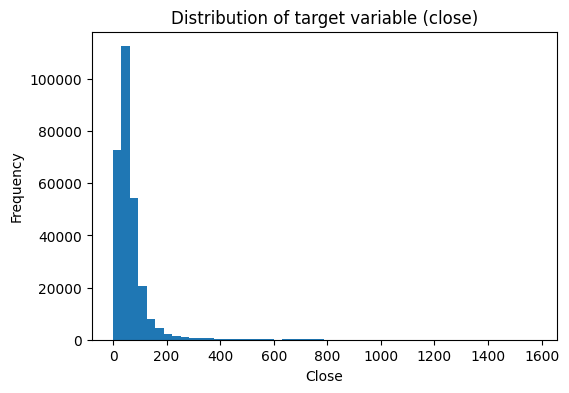

Iteration 0, Cost: 4849.599396648867
Iteration 100, Cost: 2928.5894534533722
Iteration 200, Cost: 2073.2799432968277
Iteration 300, Cost: 1621.5222274444357
Iteration 400, Cost: 1337.3123721476743
Iteration 500, Cost: 1133.7399070150839
Iteration 600, Cost: 976.5703671666055
Iteration 700, Cost: 850.5972759049981
Iteration 800, Cost: 747.8232197983742
Iteration 900, Cost: 663.2462402808543


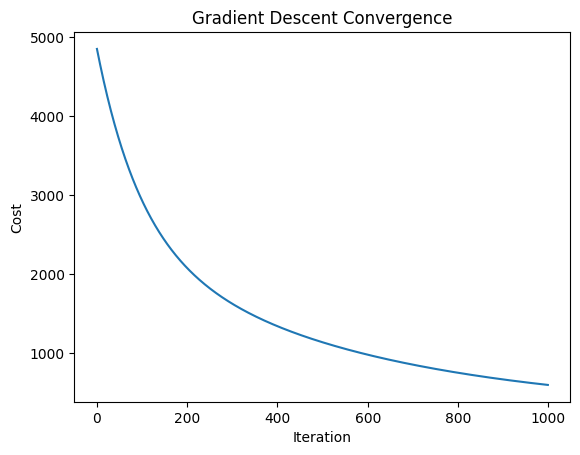

Training MSE  : 1187.8874164704957
Training RMSE : 34.465742650790155
Training RSE  : 34.46677757672372
Training R²   : 0.7889942444370062
First 5 test predictions: [[448895.75880713]
 [ 67331.51256435]
 [340944.54845187]
 [226008.56993081]
 [ 68929.56745832]]


In [1]:
#Importing libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


# Loading the data

train_df = pd.read_csv("train.csv")
test_df = pd.read_csv("test.csv")

print("Train shape:", train_df.shape)
print("\nTrain info:")
print(train_df.info())

print("\nMissing values:")
print(train_df.isna().sum())

# EDA: Target distribution 
plt.figure(figsize=(6,4))
plt.hist(train_df['close'], bins=50)
plt.title("Distribution of target variable (close)")
plt.xlabel("Close")
plt.ylabel("Frequency")
plt.show()


''' Preparing all input features denoted as x and target as y
 Dropping the column target 'close' and non-numeric column symbols
 when axis=0 it indicates rows and axis=1 indicates columns
 y is basically the target which is close'''

x = train_df.drop(['close', 'symbols'], axis=1)
y = train_df['close']


''' Convert all to numeric, fill missing with 0
pd.to_numeric converts panda objects to numeric values and if any invalid NaN 
fills missing columns with '0' 
.to_numpy converts to numpy array
.astype(float) makes sure numeric type is float
.reshape(-1,1) makes 1D array of m elements into 2D column vector of (m,1)
'''
x = x.apply(pd.to_numeric, errors='coerce').fillna(0).to_numpy().astype(float)
y = pd.to_numeric(y, errors='coerce').fillna(0).to_numpy().reshape(-1, 1)

# Number of training examples
m = x.shape[0]

# Removing columns with zero variance
'''std>0 creates boolean array if std not equal to zero then true, if its equal to zero then false
for example std = [0.0, 2.05, 0.0] then std>0 will give # non_zero_std_cols = [False, True, False]
then it selects only non zero columns because zero columns won't help in training the model
'''
# Compute std for variance check
std = np.std(x, axis=0)
non_zero_std_cols = std > 0
x = x[:, non_zero_std_cols]

# Feature scaling (manual standardization) to make sure every feature has similar scale else gradient descent won't converge properly
# Calculating mean and std
mean = np.mean(x, axis=0)
std = np.std(x, axis=0)
std[std == 0] = 1

# Standardizing
x_scaled = (x - mean) / std

# Adding bias/intercept column
'''np.ones((m, 1)) create a column vector of shape (m,1) with every row conatining 1
resulting x shape → (m, n+1)
joins the bias column and scaled features horizontally
'''
x = np.concatenate([np.ones((m, 1)), x_scaled], axis=1)

# Define compute_cost
'''m gives number of tarining examples
x = feature matrix including the bias column → shape (m, n+1)
theta = weights vector including bias weight → shape (n+1, 1)
mean squared error (cost) is returned
'''
def compute_cost(x, y, theta):
    m = len(y)
    predictions = x @ theta
    cost = (1 / (2 * m)) * np.sum((predictions - y) ** 2)
    return cost


# Defining gradient_descent
'''
m is number of training examples
predictions compute the current predicted values for all examples using current theta
Each i loop = one step of gradient descent
gradient is the derivative of the cost function
theta is the gradient descent algorithm
cost calculates for current theta
'''
def gradient_descent(x, y, theta, learning_rate, iterations):
    m = len(y)
    cost_history = []
    
    for i in range(iterations):
        predictions = x @ theta
        error = predictions - y
        gradient = (1 / m) * (x.T @ error)
        theta = theta - learning_rate * gradient
        
        cost = compute_cost(x, y, theta)
        cost_history.append(cost)
        #saves the cost for plotting
        
        # Print cost every 100 iterations
        if i % 100 == 0:
            print(f"Iteration {i}, Cost: {cost}")
    
    return theta, cost_history
    #Returns the final optimized weights (theta)...And the history of cost values for plotting


#  Initialize parameters and hyperparameters
'''
np.zeros((x.shape[1], 1)) creates a column vector of zeros of shape (number_of_features × 1)
learning_rate sets how big a step we will take
iterations=1000 sets the number of times we repeat the gradient descent
'''
theta = np.zeros((x.shape[1], 1))
learning_rate = 0.001
iterations = 1000


# Running gradient descent

final_theta, cost_history = gradient_descent(x, y, theta, learning_rate, iterations)


# Plotting cost convergence

plt.plot(cost_history)
plt.xlabel("Iteration")
plt.ylabel("Cost")
plt.title("Gradient Descent Convergence")
plt.show()


# Checking training MSE

predictions = x @ final_theta
# Training errors
errors = predictions - y

mse = np.mean(errors**2)
rmse = np.sqrt(mse)   # Root Mean Squared Error

# RSE (Residual Standard Error)
rse = np.sqrt(np.sum(errors**2) / (m - x.shape[1]))

# R-squared
ss_total = np.sum((y - np.mean(y))**2)
ss_residual = np.sum(errors**2)
r2 = 1 - (ss_residual / ss_total)

print(f"Training MSE  : {mse}")
print(f"Training RMSE : {rmse}")
print(f"Training RSE  : {rse}")
print(f"Training R²   : {r2}")


# Predictions on test set
# Preparimg test data the same way
x_test = test_df.drop(['symbols'], axis=1)
x_test = x_test.apply(pd.to_numeric, errors='coerce').fillna(0).to_numpy().astype(float)

# Safe column alignment with training data
#make sure same number of columns
num_train_cols = len(non_zero_std_cols)
num_test_cols = x_test.shape[1]
min_cols = min(num_train_cols, num_test_cols)

# Match columns between train and test before masking
x_test = x_test[:, :min_cols]
mask = non_zero_std_cols[:min_cols]#shorthand boolean mask

x_test = x_test[:, mask]#only columns with true value
x_test_scaled = (x_test - mean[:x_test.shape[1]]) / std[:x_test.shape[1]]  #standardizes x_test

m_test = x_test_scaled.shape[0]  #number of test examples
x_test_scaled = np.concatenate([np.ones((m_test, 1)), x_test_scaled], axis=1)

# Predict
y_test_pred = x_test_scaled @ final_theta
print("First 5 test predictions:", y_test_pred[:5])
